In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import fsolve

In [ ]:
a = 0.3.             #Associated with Reynolds-stress
eta = 5*10**(-3)
c = 9.65.            #Associated with dissapation
d = 0.05 
kappa = 0.09
alpha = 0.01
alpha_0 = 0.03
beta = np.pi/2

#a and c are dictate the onset of sustained turbulence.
    #Not possible to get this to form at the same Re as WF so has been scaled. 


def A(q):  #Reynolds-stress clousure
    return a * (np.sqrt(q**2 + eta**2) - eta)

def eps(q, Re): #Closure for \eps_0 dissapation term
    return (c/Re) * q

def v_t (q, Re): #turbulent difusivity (closure?)
    return d*Re*q

#The above functions constitute the turbulrence closures


def u_dot (q, u, Re): 
    return (alpha+(beta**2)/Re)*(1-u)-beta*A(q)

def q_dot (q, Re): 
    return 1/2 *beta*A(q)- 2*alpha*q - eps(q,Re)

In [72]:
def u_nullcline(q, Re, alpha, beta, A):
    return 1 - (beta*Re*A(q))/(alpha*Re + beta**2)

def q_nullcline(q, Re, alpha, beta, A, eps):
    return (4*alpha*q + 2*eps(q, Re))/(beta*A(q))

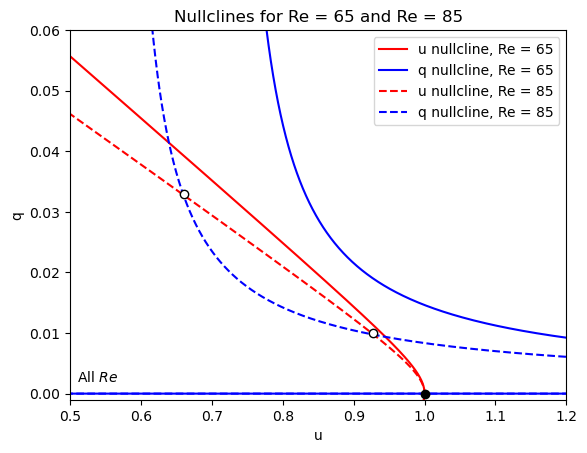

In [ ]:
q_pos = np.linspace(0, 0.06, 800)
q_axis1 = np.linspace(-0.005, 0.06, 800)
u_vals = np.linspace(0.5, 1.1, 800)

Re = [65, 85] 

linesu = ['r', 'r--']
linesq = ['b', 'b--']

plt.figure
for i in range (2): 
    u_nc = u_nullcline(q_axis1, Re[i], alpha, beta, A)
    q_nc = q_nullcline(q_axis1, Re[i], alpha, beta, A, eps)
    plt.plot(u_nc, q_axis1, linesu[i], label = f'u nullcline, Re = {Re[i]}')
    plt.plot(q_nc, q_axis1, linesq[i], label = f'q nullcline, Re = {Re[i]}')
    plt.xlabel('u')
    plt.ylabel('q')

fp1x, fp1y = np.array([1]), np.array([0])
fp2x, fp2y = np.array([0.927, 0.66]), np.array([0.01, 0.033])
plt.scatter(fp1x, fp1y, c= 'k', zorder=2)
plt.scatter (fp2x, fp2y, c='w', edgecolors='k', zorder=2)

plt.title('Nullclines for Re = 65 and Re = 85')
plt.xlim(0.5, 1.2)
plt.ylim(-0.001, 0.06)
plt.text(0.51, 0.002, r"All $Re$")
plt.legend () 
plt.show()

In [85]:
def q_Jacobian(q, u, Re, alpha, beta, a, c, eta): 
    dAdq = a*q/np.sqrt(q**2 + eta**2)
    deps_dq = c/Re

    J_11 = 1/2 * beta* u * dAdq - 2*alpha - deps_dq
    J_12 = 1/2 * beta * A(q)
    J_21 = -beta* dAdq 
    J_22 = - (alpha + (beta**2)/Re)

    return np.array ([[J_11, J_12], [J_21, J_22]])

def bifurcation(q, Re_vals, alpha, beta, a, c, eta):
    q_stable = []
    Re_stable = []
    q_unstable = []
    Re_unstable=[]

    for Re in Re_vals:
        for i in range (len(q)-1):
            if q_dot(q[i],Re)*q_dot(q[i+1], Re) < 0 : 
                 u_i = q_nullcline(q[i], Re, alpha, beta, A, eps) #u is determined by the nullcline 
                 J = q_Jacobian(q[i], u_i, Re, alpha, beta, a, c, eta) 

                 eigvals = np.linalg.eigvals(J) 

                 if np.all(np.real(eigvals) < 0):
                    Re_stable.append(Re)
                    q_stable.append(q[i])
                 else:
                    Re_unstable.append(Re)
                    q_unstable.append(q[i])

            else: 
                Re_stable = Re_stable
                q_stable = q_stable
                q_unstable = q_unstable
                Re_unstable = Re_unstable


    return Re_stable, q_stable, Re_unstable, q_unstable

Text(0, 0.5, 'q')

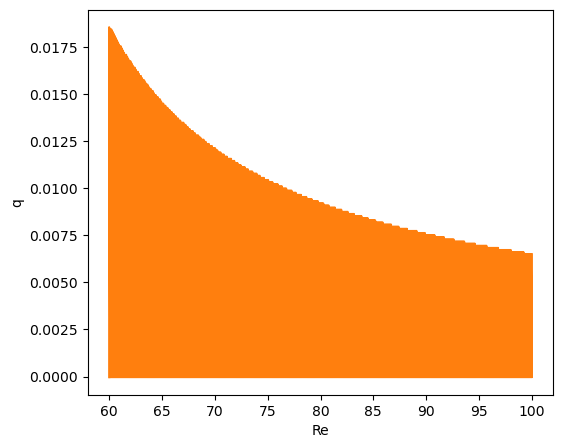

In [87]:
q_axis2 = np.linspace(-0.005, 0.04, 400)
Re_vals = np.linspace(60,100, 400)

re_s, q_s, re_us, q_us = bifurcation(q_axis2, Re_vals, alpha, beta, a, c, eta)

plt.figure(figsize=(6,5))
plt.plot(re_s, q_s, label='stable')
plt.plot(re_us, q_us, label='unstable')

plt.xlabel("Re")
plt.ylabel("q")


In [88]:
print(f"Re_stable length: {len(re_s)}")
print(f"Re_unstable length: {len(re_us)}")
print(f"First few stable points: {list(zip(re_s[:5], q_s[:5]))}")
print(f"First few unstable points: {list(zip(re_us[:5], q_us[:5]))}")

Re_stable length: 0
Re_unstable length: 800
First few stable points: []
First few unstable points: [(np.float64(60.0), np.float64(-3.7593984962405735e-05)), (np.float64(60.0), np.float64(0.018571428571428572)), (np.float64(60.100250626566414), np.float64(-3.7593984962405735e-05)), (np.float64(60.100250626566414), np.float64(0.01845864661654135)), (np.float64(60.200501253132835), np.float64(-3.7593984962405735e-05))]
